In [2]:
!pip install scanpy
!pip install scvi-tools
from __future__ import annotations
import pandas as pd
import numpy as np
import scvi
import scanpy as sc
import sys
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scvi
import scanpy as sc
import matplotlib
from matplotlib import rc_context
import csv
import os
seed=123
#dependencies
!pip install scvi-tools
!pip install scikit-misc
!pip install scanpy
!pip install leidenalg

c:\Users\RICHMOND\AppData\Local\r-miniconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
os.chdir("C:/Users/RICHMOND/Documents/Richmond/singlecell_rein/script_exemple/data2/xemuin")

In [4]:
adata_spatial = sc.read_h5ad("spatial_adata_xenium_cosmx_zenodo.h5ad")
adata_immune= sc.read_h5ad("C:/Users/RICHMOND/Documents/Richmond/singlecell_rein/script_exemple/data2/adata_immune_annot_final.h5ad")

In [5]:
adata_spatial.obs

,cell_id,orig_ident,tech,nCount_RNA,nFeature_RNA,annotation_updated,niches_annotation_based,Condition,Age,Sex,iPT_iLOH_ME,immune_ME,immune_cell_annotation_combined,Immune_ME_20um,iPT_iLOH_ME_20um
HK3626_1,aaaajaon-1,HK3626,Xenium,1182,666,CNT,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown
HK3626_2,aaaakhfd-1,HK3626,Xenium,1089,623,IC A,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown
HK3626_3,aaabgbfk-1,HK3626,Xenium,330,266,PC,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown
HK3626_4,aaabmega-1,HK3626,Xenium,763,480,IC B,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown
HK3626_5,aaacblpm-1,HK3626,Xenium,1012,555,DCT,DCT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HK2695_1283_34-16,c_1_34_1283,HK2695,CosMx,53,36,PT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Unknown
HK2695_1288_34-16,c_1_34_1288,HK2695,CosMx,77,50,CNT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Distal ME
HK2695_1290_34-16,c_1_34_1290,HK2695,CosMx,71,52,CNT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Distal ME
HK2695_1291_34-16,c_1_34_1291,HK2695,CosMx,41,35,TAL,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Unknown


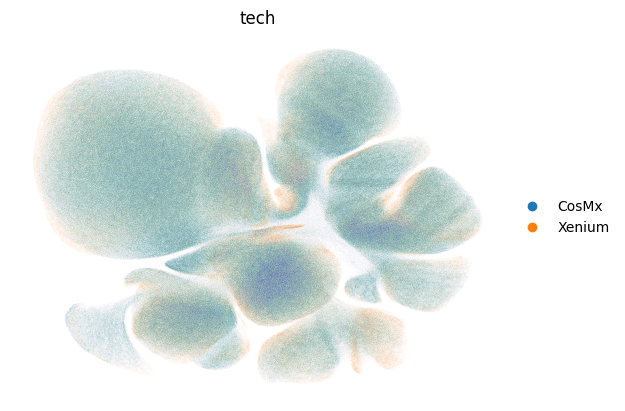

In [5]:
sc.pl.umap(adata_spatial, color="tech", ncols=5, frameon=False)

In [6]:
adata_spatial.obs["niches_annotation_based"].value_counts()

niches_annotation_based
PT niche            1149744
LOH niche            552860
Fibroblast niche     423236
CNT niche            379022
PC niche             327997
Unknown              308531
iPT niche            281041
DCT niche            280350
Glomerular niche     219552
iLOH niche           158342
Vascular niche       139049
Immune niche         118138
Name: count, dtype: int64

In [7]:
adata_spatial.obs["annotation_updated"].value_counts()

annotation_updated
PT            1215229
Fibroblast     471859
TAL            461024
iPT            365321
EC_Peritub     315892
PC             268625
Immune         254015
DCT            208651
CNT            183121
iTAL           166559
IC A           121825
VSMC            77650
Podo            59726
EC_glom         54538
IC B            27880
EC_DVR          23665
PEC             23330
MC1             22463
DTL_ATL         15469
EC_Lymph         1020
Name: count, dtype: int64

In [7]:
from anndata import AnnData
import scanpy as sc
import squidpy as sq
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [04:55<00:00,  3.38/s]


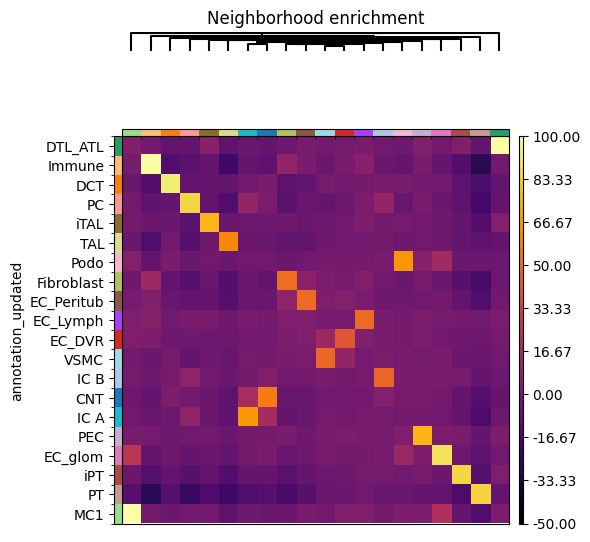

In [8]:
sq.gr.spatial_neighbors(
    adata_spatial,
    n_neighs=1,
    coord_type="generic",
    key_added = "1_nn"
)

sq.gr.nhood_enrichment(adata_spatial, cluster_key="annotation_updated", connectivity_key = "1_nn")
sq.pl.nhood_enrichment(
    adata_spatial,
    cluster_key="annotation_updated",
    method="average",
    cmap="inferno",
    connectivity_key = "1_nn",
    vmin=-50,
    vmax=100,
    figsize=(5, 5),
)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [17:20<00:00,  1.04s/]


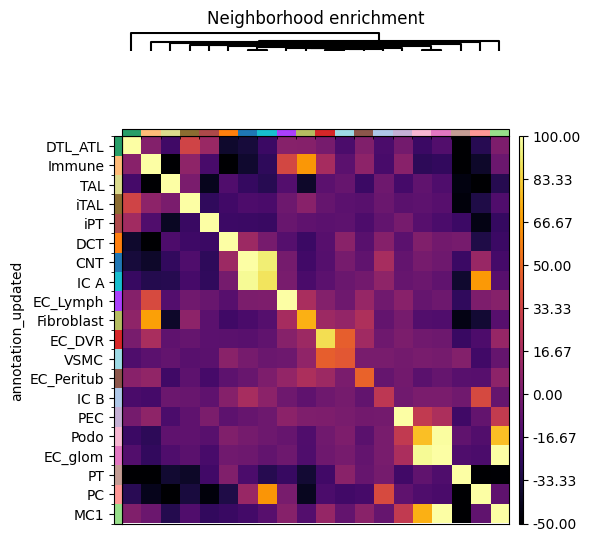

In [11]:
sq.gr.spatial_neighbors(
    adata_spatial,
    n_neighs=20,
    coord_type="generic",
    key_added = "20_nn"
)

sq.gr.nhood_enrichment(adata_spatial, cluster_key="annotation_updated", connectivity_key = "20_nn")
sq.pl.nhood_enrichment(
    adata_spatial,
    cluster_key="annotation_updated",
    method="average",
    cmap="inferno",
    connectivity_key = "20_nn",
    vmin=-50,
    vmax=100,
    figsize=(5, 5),
)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [46:51<00:00,  2.81s/] 


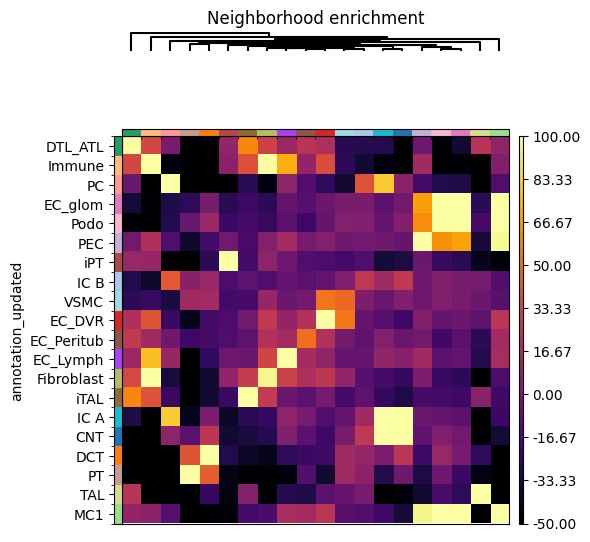

In [12]:
sq.gr.spatial_neighbors(
    adata_spatial,
    n_neighs=100,
    coord_type="generic",
    key_added = "100_nn"
)

sq.gr.nhood_enrichment(adata_spatial, cluster_key="annotation_updated", connectivity_key = "100_nn")
sq.pl.nhood_enrichment(
    adata_spatial,
    cluster_key="annotation_updated",
    method="average",
    cmap="inferno",
    connectivity_key = "100_nn",
    vmin=-50,
    vmax=100,
    figsize=(5, 5),
)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [04:45<00:00,  3.50/s]


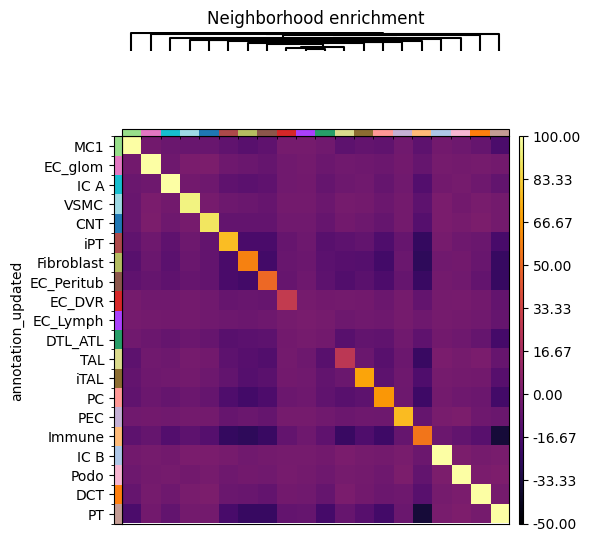

In [13]:
sq.gr.spatial_neighbors(
    adata_spatial,
    radius=0.02,
    coord_type="generic",
    key_added = "20_micron"
)

sq.gr.nhood_enrichment(adata_spatial, cluster_key="annotation_updated", connectivity_key = "20_micron")
sq.pl.nhood_enrichment(
    adata_spatial,
    cluster_key="annotation_updated",
    connectivity_key = "20_micron",
    method="average",
    cmap="inferno",
    vmin=-50,
    vmax=100,
    figsize=(5, 5),
)

In [17]:
sq.gr.spatial_neighbors(
    adata_spatial,
    radius=0.02,
    coord_type="generic",
)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


In [18]:
adata_spatial

AnnData object with n_obs × n_vars = 4337862 × 5443
    obs: 'cell_id', 'orig_ident', 'tech', 'nCount_RNA', 'nFeature_RNA', 'annotation_updated', 'niches_annotation_based', 'Condition', 'Age', 'Sex', 'iPT_iLOH_ME', 'immune_ME', 'immune_cell_annotation_combined', 'Immune_ME_20um', 'iPT_iLOH_ME_20um'
    var: 'n_cells'
    uns: 'orig_ident_colors', 'tech_colors', '1_nn_neighbors', 'annotation_updated_nhood_enrichment', '20_nn_neighbors', '100_nn_neighbors', '20_micron_neighbors', 'spatial_neighbors'
    obsm: 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'
    obsp: '1_nn_connectivities', '1_nn_distances', '20_nn_connectivities', '20_nn_distances', '100_nn_connectivities', '100_nn_distances', '20_micron_connectivities', '20_micron_distances', 'spatial_connectivities', 'spatial_distances'

(array([3.655578e+06, 6.001040e+05, 7.467000e+04, 7.028000e+03,
        4.700000e+02, 1.200000e+01, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36.,

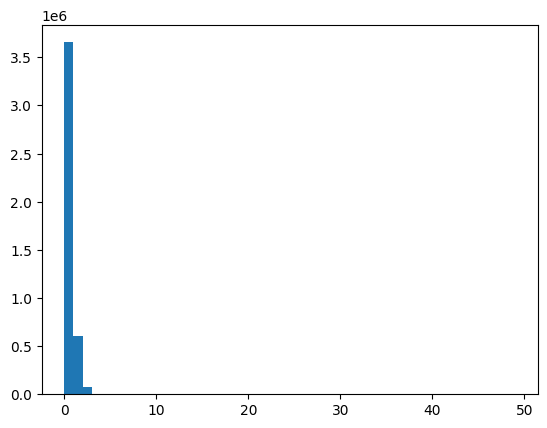

In [19]:
neighbor_check = []
for i in range(adata_spatial.obsp["spatial_connectivities"].shape[0]):
  neighbor_check.append(np.sum(adata_spatial.obsp["spatial_connectivities"][i]))

# total number of neighbors
plt.hist(neighbor_check, bins = np.arange(0, 50, 1))

In [20]:
immuneCells = (np.where(adata_spatial.obs['annotation_updated']=="Immune")[0])
neighbors_immune = np.where(adata_spatial.obsp["spatial_connectivities"][:, immuneCells].sum(axis=1) > 0)[0]
adata_spatial.obs["immune_neighbors"] = 0

for i in neighbors_immune:
  adata_spatial.obs["immune_neighbors"].iloc[i] = np.sum(adata_spatial.obsp["spatial_connectivities"][i, immuneCells])

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\1330063311.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata_spatial.obs["immune_neighbors"].iloc[i] = np.sum(adata_spatial.obsp["spatial_connectivities"][i, immuneCells])
C:\Users

(array([4.304402e+06, 3.275200e+04, 7.030000e+02, 5.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19.]),
 <BarContainer object of 19 artists>)

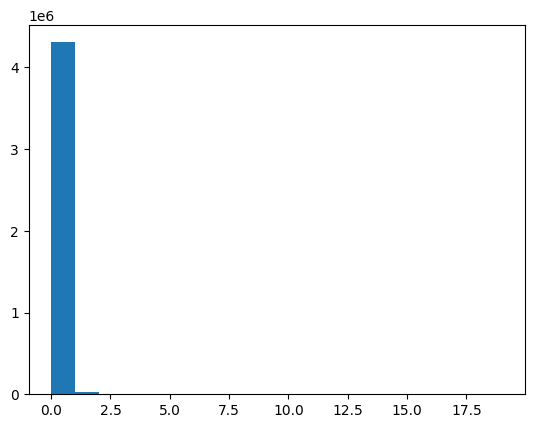

In [21]:
plt.hist(adata_spatial.obs["immune_neighbors"], bins = np.arange(0, 20, 1))

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\2002555807.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_PT.obs["ImmuneNeighbor"] = (adata_PT.obs["immune_neighbors"] > 0).astype('str')


ImmuneNeighbor
False    1206896
True        8333
Name: count, dtype: int64


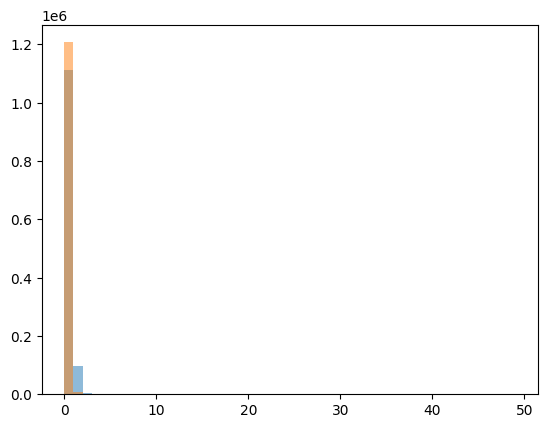

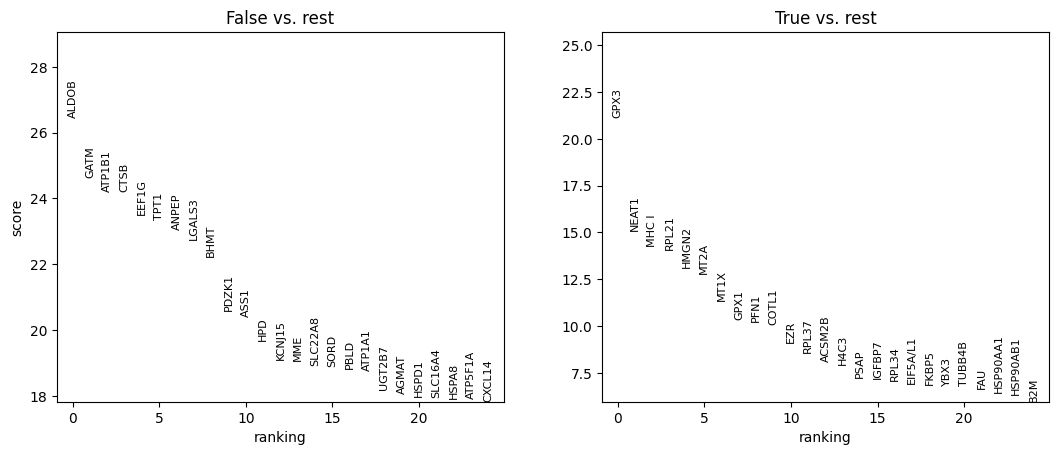

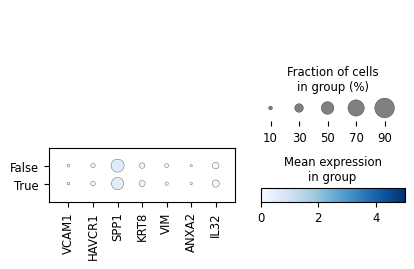

In [23]:
adata_PT = adata_spatial[adata_spatial.obs['annotation_updated'].isin(["PT"]), :]

neighbor_check = []
for i in range(adata_PT.obsp["spatial_connectivities"].shape[0]):
  neighbor_check.append(np.sum(adata_PT.obsp["spatial_connectivities"][i]))

# total number of neighbors for PT cells
plt.hist(neighbor_check, bins = np.arange(0, 50, 1), alpha = 0.5)

plt.hist(adata_PT.obs["immune_neighbors"], bins = np.arange(0, 20, 1), alpha = 0.5)

adata_PT.obs["ImmuneNeighbor"] = (adata_PT.obs["immune_neighbors"] > 0).astype('str')

print(adata_PT.obs["ImmuneNeighbor"].value_counts())

adata_PT.X = adata_PT.layers["counts"]
sc.pp.log1p(adata_PT)
sc.tl.rank_genes_groups(adata_PT, groupby='ImmuneNeighbor', method='wilcoxon', pts = True)
sc.pl.rank_genes_groups(adata_PT, n_genes=25, sharey=False)
df = sc.get.rank_genes_groups_df(adata_PT, group="True")
df.to_csv('CosMx_PT_immuneNeighbor.csv')

df = sc.get.rank_genes_groups_df(adata_PT, group="False")
df.to_csv('CosMx_PT_NoimmuneNeighbor.csv')

markers = ["VCAM1", "HAVCR1", "SPP1", "KRT8", "VIM", "ANXA2", "IL32"]

sc.pl.dotplot(adata_PT, markers, groupby='ImmuneNeighbor', cmap='Blues', log = False, vmin = 0, vmax = 5, dot_max = 0.9)

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\888417964.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_PT.obs["ImmuneNeighbor"] = (adata_PT.obs["immune_neighbors"] > 0).astype('str')


ImmuneNeighbor
False    1206896
True        8333
Name: count, dtype: int64


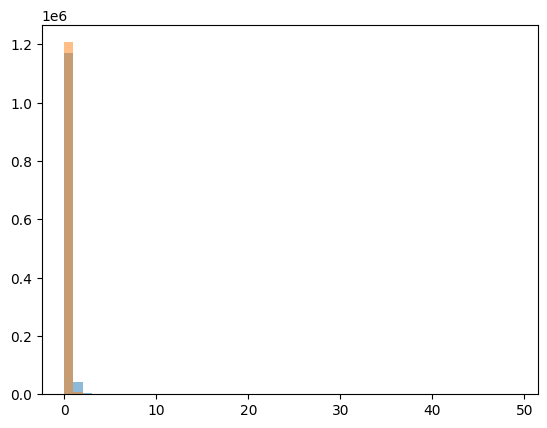

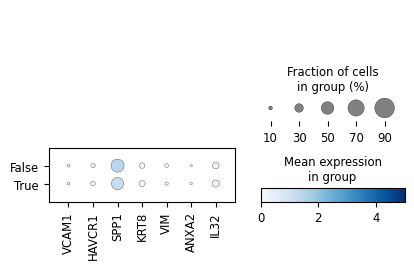

In [24]:
adata_PT = adata_spatial[adata_spatial.obs['annotation_updated'].isin(["PT"]), :]

neighbor_check = []
for i in range(adata_PT.obsp["spatial_connectivities"].shape[0]):
  neighbor_check.append(np.sum(adata_spatial.obsp["spatial_connectivities"][i]))

# total number of neighbors for PT cells
plt.hist(neighbor_check, bins = np.arange(0, 50, 1), alpha = 0.5)

plt.hist(adata_PT.obs["immune_neighbors"], bins = np.arange(0, 20, 1), alpha = 0.5)

adata_PT.obs["ImmuneNeighbor"] = (adata_PT.obs["immune_neighbors"] > 0).astype('str')

print(adata_PT.obs["ImmuneNeighbor"].value_counts())


sc.pl.dotplot(adata_PT, markers, groupby='ImmuneNeighbor', cmap='Blues', log = False, vmin = 0, vmax = 5, dot_max = 0.9)

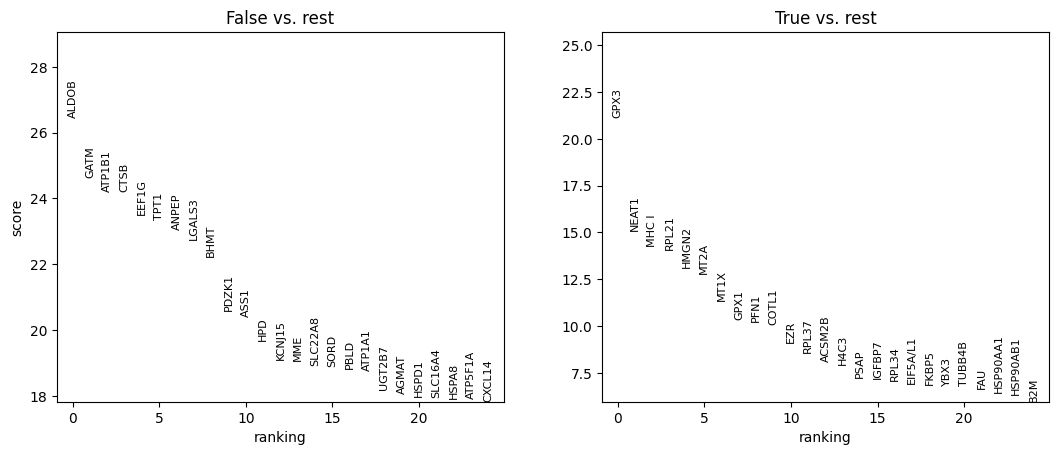

In [27]:
adata_PT.X = adata_PT.layers["counts"]
sc.pp.log1p(adata_PT)
sc.tl.rank_genes_groups(adata_PT, groupby='ImmuneNeighbor', method='wilcoxon', pts = True)
sc.pl.rank_genes_groups(adata_PT, n_genes=25, sharey=False)

df = sc.get.rank_genes_groups_df(adata_PT, group="True")
df.to_csv('CosMx_iPT_immuneNeighbor.csv')

df = sc.get.rank_genes_groups_df(adata_PT, group="False")
df.to_csv('CosMx_iPT_NoimmuneNeighbor.csv')

(array([3.655578e+06, 6.001040e+05, 7.467000e+04, 7.028000e+03,
        4.700000e+02, 1.200000e+01, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36.,

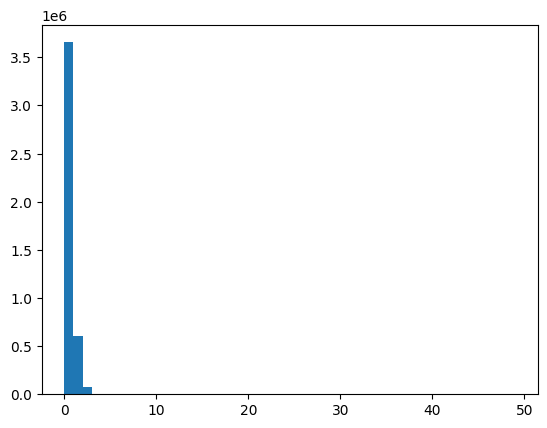

In [28]:
neighbor_check = []
for i in range(adata_spatial.obsp["spatial_connectivities"].shape[0]):
  neighbor_check.append(np.sum(adata_spatial.obsp["spatial_connectivities"][i]))

# total number of neighbors
plt.hist(neighbor_check, bins = np.arange(0, 50, 1))

In [29]:
df = pd.DataFrame()

for i in adata_spatial.obs['annotation_updated'].unique():
    neighborType = (np.where(adata_spatial.obs['annotation_updated']==i)[0])
    numberNeighbors = pd.DataFrame(adata_spatial.obsp["spatial_connectivities"][:, neighborType].sum(axis=1))
    df = pd.concat([df, numberNeighbors], axis=1)

df.columns = adata_spatial.obs['annotation_updated'].unique()
df["index"] = adata_spatial.obs.index
df.set_index("index", inplace=True)

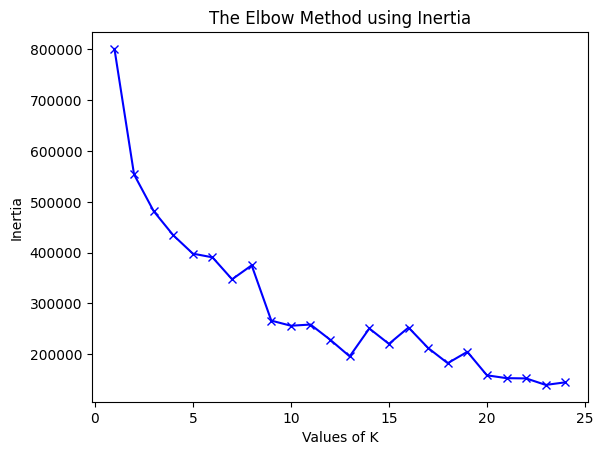

In [30]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

inertias = []
k = range(1, 25)

# dissimilarity would not be defined for a single cluster, thus, minimum number of clusters should be 2
for K in k:
    # Create a MiniBatchKMeans object, arbitrarily choosing 10 clusters
    kmeans = MiniBatchKMeans(n_clusters=K)
    # Fit the model to the data
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

plt.plot(k, inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

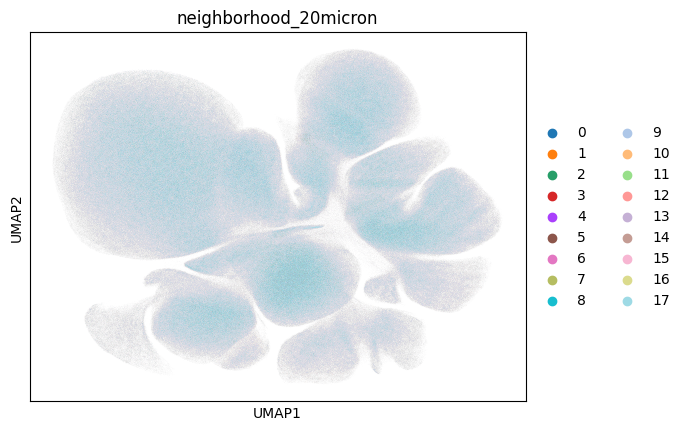

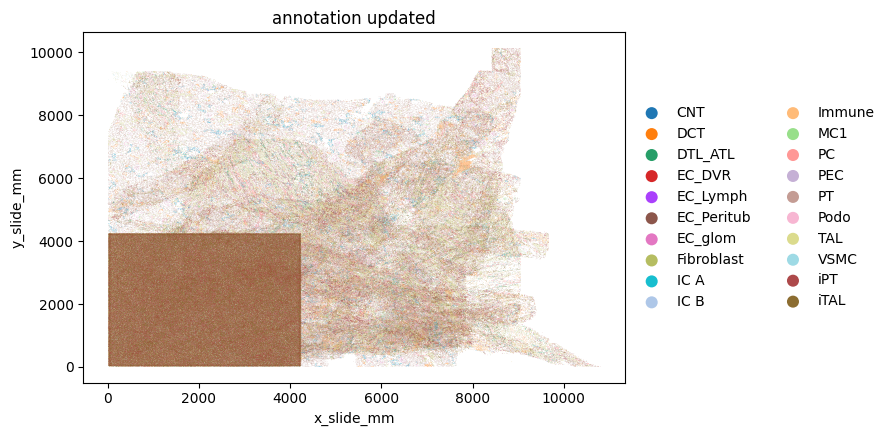

In [34]:
# Create a MiniBatchKMeans object, arbitrarily choosing 10 clusters
kmeans = MiniBatchKMeans(n_clusters=18)

# Fit the model to the data
kmeans.fit(df)

# Predict the cluster labels for each data point
labels = kmeans.predict(df)

adata_spatial.obs["neighborhood_20micron"] = labels
adata_spatial.obs["neighborhood_20micron"] = adata_spatial.obs["neighborhood_20micron"].astype('str')

sc.pl.umap(adata_spatial, color = "neighborhood_20micron")

# ── Option 2 : ajouter x/y dans obs depuis obsm['spatial'] ───
adata_spatial.obs['x_slide_mm'] = adata_spatial.obsm['spatial'][:, 0]
adata_spatial.obs['y_slide_mm'] = adata_spatial.obsm['spatial'][:, 1]

# Puis relancer sc.pl.scatter
sc.pl.scatter(
    adata_spatial,
    x     = "x_slide_mm",
    y     = "y_slide_mm",
    color = "annotation_updated",
    size  = 0.2,
)


In [32]:
# Vérifier les colonnes disponibles
print("Colonnes obs :", adata_spatial.obs.columns.tolist())
print("\nobsm disponibles :", list(adata_spatial.obsm.keys()))

# Vérifier les coordonnées spatiales
print("\nContenu obsm['spatial'] :", adata_spatial.obsm['spatial'].shape)
print("Contenu obsm['spatial_fov'] :", adata_spatial.obsm['spatial_fov'].shape)

Colonnes obs : ['cell_id', 'orig_ident', 'tech', 'nCount_RNA', 'nFeature_RNA', 'annotation_updated', 'niches_annotation_based', 'Condition', 'Age', 'Sex', 'iPT_iLOH_ME', 'immune_ME', 'immune_cell_annotation_combined', 'Immune_ME_20um', 'iPT_iLOH_ME_20um', 'immune_neighbors', 'neighborhood_20micron']

obsm disponibles : ['X_umap', 'spatial', 'spatial_fov']

Contenu obsm['spatial'] : (4337862, 2)
Contenu obsm['spatial_fov'] : (4337862, 2)


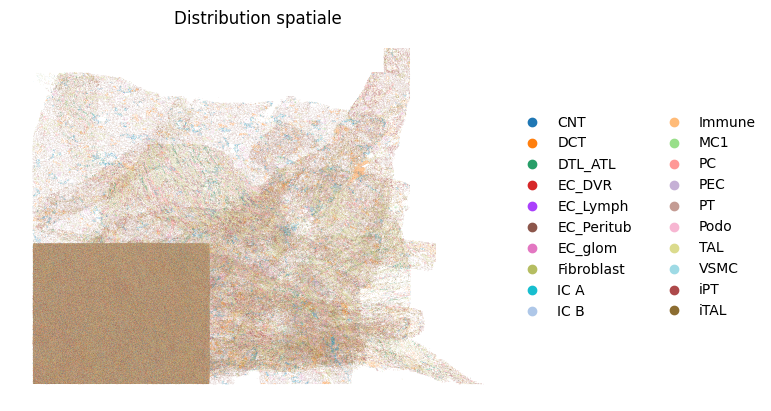

In [33]:
# ── Option 1 : utiliser sc.pl.embedding avec obsm['spatial'] ──
sc.pl.embedding(
    adata_spatial,
    basis  = "spatial",
    color  = "annotation_updated",
    size   = 0.2,
    frameon = False,
    title  = "Distribution spatiale"
)


In [35]:
df = adata_spatial.obs["neighborhood_20micron"].value_counts().to_frame()
df.index = adata_spatial.obs["neighborhood_20micron"].value_counts().index

df['sampleBreakdown'] = object
df['neighbors'] = object
df['composition'] = object

df = df.sort_index(ascending=True)

In [40]:
for i in df.index:
    counts_sample = []
    for j in adata_spatial.obs["Condition"].unique():
        counts_sample.append(adata_spatial.obs[(adata_spatial.obs['Condition'] == j) & (adata_spatial.obs['neighborhood_20micron'] == i)].shape[0])
    df.at[i,'sampleBreakdown'] = counts_sample

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\902495469.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S1 = df.sampleBreakdown[i]
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\902495469.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10')


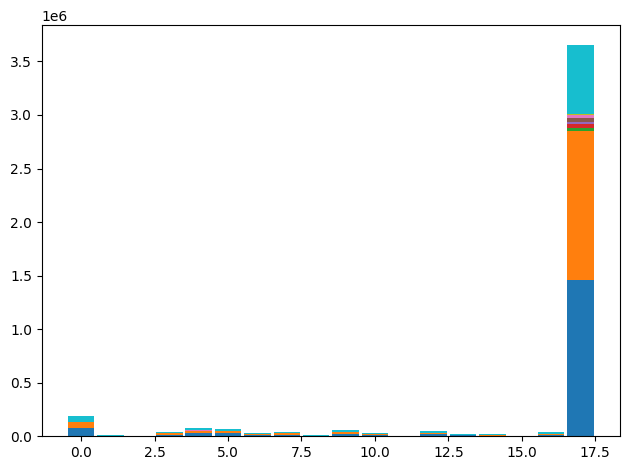

In [41]:

width = 0.9

# Loop over each cell type and create a stacked bar plot of the "sample" category
for i, cell_type in enumerate(df.index):
    ind = np.arange(1)
    S1 = df.sampleBreakdown[i]

    palette = plt.cm.get_cmap('tab10')
    bottom = 0
    for j in range(len(S1)):
          plt.bar(i, S1[j],bottom = bottom, width = width, color = palette(j))
          bottom = bottom + S1[j]
    # Show the plot
plt.tight_layout()

plt.show()

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\827520817.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10')
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\827520817.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S1 = df.neighbors[i]


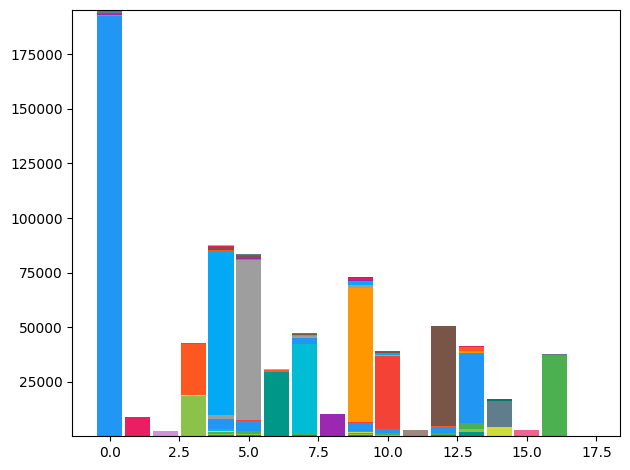

In [49]:
for i in df.index:   
    type_array = (np.where(adata_spatial.obs["neighborhood_20micron"]==i)[0])
    ## find nearest neighbors
    connectivities_cellType = adata_spatial.obsp["spatial_connectivities"][type_array,:] # make an matrix with just cell type i comprising rows
    sum = connectivities_cellType.sum()
    nn = []
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        type2_array = (np.where(adata_spatial.obs["annotation_updated"]==j)[0])
        nn.append(connectivities_cellType[:,type2_array].sum())
        #nn.append(connectivities_cellType[:,type2_array].sum()/(sum))
        df.at[i,"neighbors"] = nn

width = 0.9

palette = plt.cm.get_cmap('tab10')

# Loop over each cell type and create a stacked bar plot of the "sample" category
for i, cell_type in enumerate(df.index):
    ind = np.arange(1)
    S1 = df.neighbors[i]
    bottom = 0
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        plt.bar(i, S1[j_index],bottom = bottom, width = width, color = colors[j])
        bottom = bottom + S1[j_index]
        #print(j)

    # Show the plot
plt.tight_layout()

plt.show()

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3149182879.py:10: RuntimeWarning: invalid value encountered in scalar divide
  nn.append(connectivities_cellType[:,type2_array].sum()/(sum))
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3149182879.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10')
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3149182879.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S1 = df.neighbors[i]


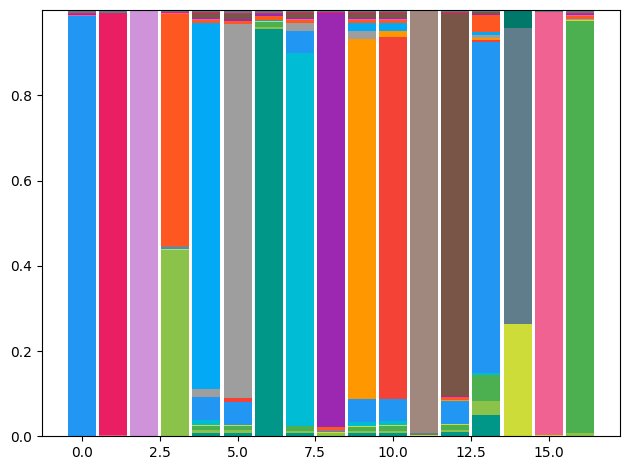

In [50]:
for i in df.index:   
    type_array = (np.where(adata_spatial.obs["neighborhood_20micron"]==i)[0])
    ## find nearest neighbors
    connectivities_cellType = adata_spatial.obsp["spatial_connectivities"][type_array,:] # make an matrix with just cell type i comprising rows
    sum = connectivities_cellType.sum()
    nn = []
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        type2_array = (np.where(adata_spatial.obs["annotation_updated"]==j)[0])
        #nn.append(connectivities_cellType[:,type2_array].sum())
        nn.append(connectivities_cellType[:,type2_array].sum()/(sum))
        df.at[i,"neighbors"] = nn
        

width = 0.9

palette = plt.cm.get_cmap('tab10')

# Loop over each cell type and create a stacked bar plot of the "sample" category
for i, cell_type in enumerate(df.index):
    ind = np.arange(1)
    S1 = df.neighbors[i]
    bottom = 0
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        plt.bar(i, S1[j_index],bottom = bottom, width = width, color = colors[j])
        bottom = bottom + S1[j_index]
        #print(j)

    # Show the plot
plt.tight_layout()

plt.show()

In [46]:
adata_spatial.obs["annotation_updated"].value_counts()

annotation_updated
PT            1215229
Fibroblast     471859
TAL            461024
iPT            365321
EC_Peritub     315892
PC             268625
Immune         254015
DCT            208651
CNT            183121
iTAL           166559
IC A           121825
VSMC            77650
Podo            59726
EC_glom         54538
IC B            27880
EC_DVR          23665
PEC             23330
MC1             22463
DTL_ATL         15469
EC_Lymph         1020
Name: count, dtype: int64

In [47]:
colors = { # Tubulaire sain
    'PT'        : '#2196F3',   # bleu
    'TAL'       : '#03A9F4',   # bleu clair
    'DCT'       : '#00BCD4',   # cyan
    'CNT'       : '#009688',   # teal
    'PC'        : '#4CAF50',   # vert
    'IC A'      : '#8BC34A',   # vert clair
    'IC B'      : '#CDDC39',   # jaune-vert
    'DTL_ATL'   : '#00796B',   # teal foncé
    # Tubulaire lésé
    'iPT'       : '#FF9800',   # orange
    'iTAL'      : '#FF5722',   # orange foncé
    # Glomérulaire
    'Podo'      : '#9C27B0',   # violet
    'EC_glom'   : '#E91E63',   # rose
    'PEC'       : '#F06292',   # rose clair
    'MC1'       : '#CE93D8',   # violet clair
    # Endothélial / Stromal
    'EC_Peritub': '#795548',   # marron
    'EC_DVR'    : '#A1887F',   # marron clair
    'EC_Lymph'  : '#BCAAA4',   # beige
    'VSMC'      : '#607D8B',   # gris-bleu
    'Fibroblast': '#9E9E9E',   # gris
    # Immun
    'Immune'    : '#F44336',   # rouge
}

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3597131002.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10')
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3597131002.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S1 = df.composition[i]


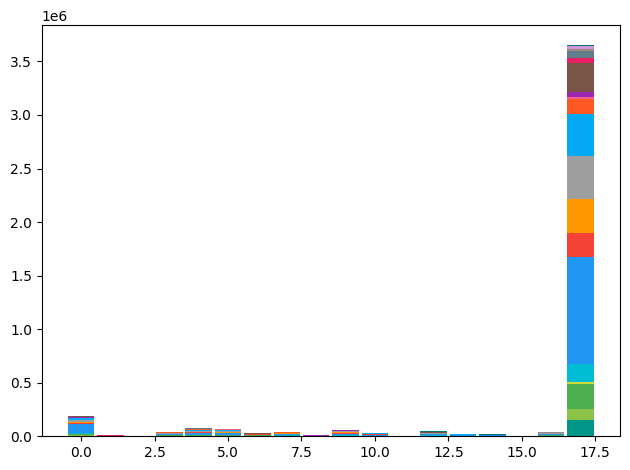

In [52]:
for i in df.index:
    counts_sample = []
    for j in adata_spatial.obs["annotation_updated"].unique():
        counts_sample.append(adata_spatial.obs[(adata_spatial.obs['annotation_updated'] == j) & (adata_spatial.obs['neighborhood_20micron'] == i)].shape[0])
    sumtotal = (df.loc[i,"count"])
    #counts_sample = list(map(lambda x: x / sumtotal, counts_sample))
    df.at[i,'composition'] = counts_sample

width = 0.9

palette = plt.cm.get_cmap('tab10')

# Loop over each cell type and create a stacked bar plot of the "sample" category
for i, cell_type in enumerate(df.index):
    ind = np.arange(1)
    S1 = df.composition[i]
    bottom = 0
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        plt.bar(i, S1[j_index],bottom = bottom, width = width, color = colors[j])
        bottom = bottom + S1[j_index]
        
    # Show the plot
plt.tight_layout()

plt.show()

C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3345826979.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10')
C:\Users\RICHMOND\AppData\Local\Temp\ipykernel_17716\3345826979.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S1 = df.composition[i]


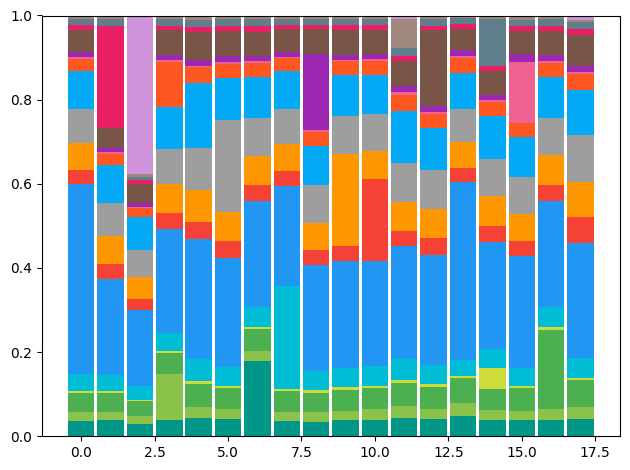

In [53]:
for i in df.index:
    counts_sample = []
    for j in adata_spatial.obs["annotation_updated"].unique():
        counts_sample.append(adata_spatial.obs[(adata_spatial.obs['annotation_updated'] == j) & (adata_spatial.obs['neighborhood_20micron'] == i)].shape[0])
    sumtotal = (df.loc[i,"count"])
    counts_sample = list(map(lambda x: x / sumtotal, counts_sample))
    df.at[i,'composition'] = counts_sample

width = 0.9

palette = plt.cm.get_cmap('tab10')

# Loop over each cell type and create a stacked bar plot of the "sample" category
for i, cell_type in enumerate(df.index):
    ind = np.arange(1)
    S1 = df.composition[i]
    bottom = 0
    for j_index, j in enumerate(adata_spatial.obs["annotation_updated"].unique()):
        plt.bar(i, S1[j_index],bottom = bottom, width = width, color = colors[j])
        bottom = bottom + S1[j_index]
        
    # Show the plot
plt.tight_layout()

plt.show()

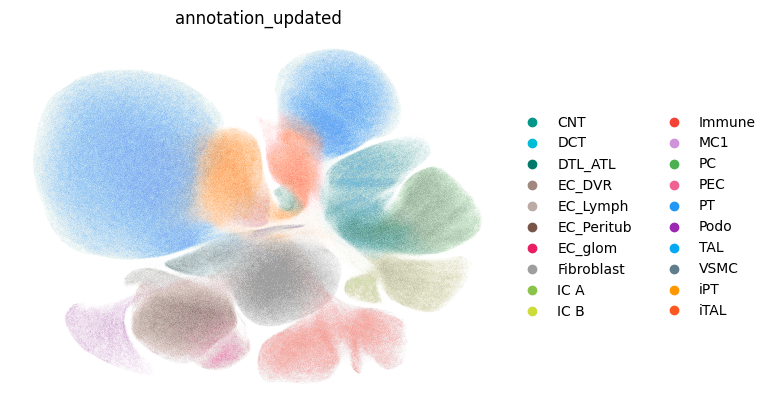

In [55]:
sc.pl.umap(adata_spatial, color = "annotation_updated", palette = colors, frameon = False)

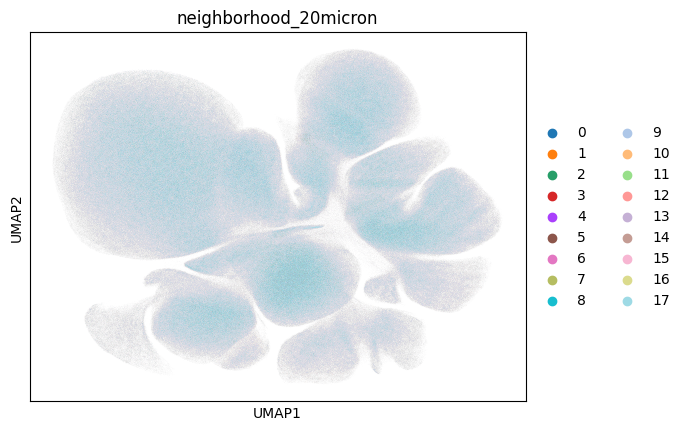

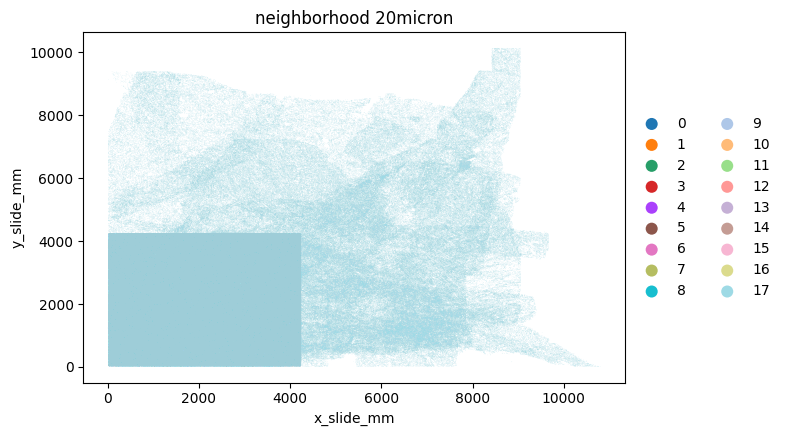

In [56]:
sc.pl.umap(adata_spatial, color = "neighborhood_20micron")

sc.pl.scatter(
    adata_spatial,
    x="x_slide_mm",
    y="y_slide_mm",
    color="neighborhood_20micron",
    size=0.2,
)


In [62]:
adata_spatial.obs["immune_cell_annotation_combined"].value_counts()

immune_cell_annotation_combined
Unknown       4083852
Macro          130454
CD8+            46793
CD4+            42982
B               16270
Neutrophil       7873
Plasma           5422
NK               3261
Baso_Mast         622
cDC               219
pDC               112
mDC                 2
Name: count, dtype: int64

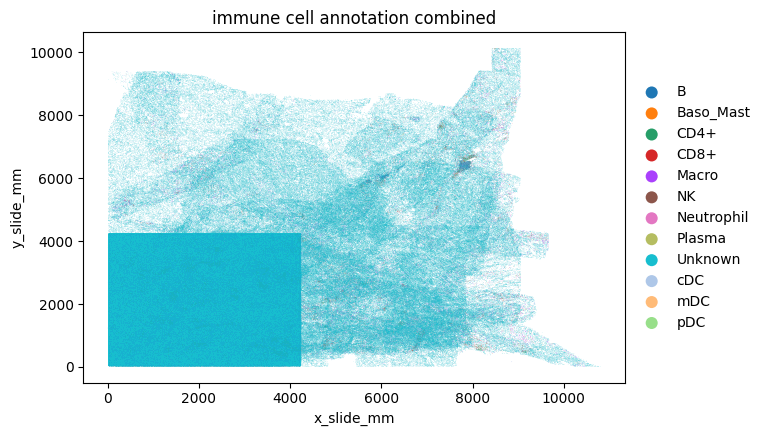

In [63]:
sc.pl.scatter(
    adata_spatial,
    x="x_slide_mm",
    y="y_slide_mm",
    color="immune_cell_annotation_combined",
    size=0.2,
)


In [1]:
print(adata_spatial.obs['annot_final2'].value_counts())

NameError: name 'adata_spatial' is not defined

In [ ]:
adata_spatial

In [26]:
adata_spatial.obs

,cell_id,orig_ident,tech,nCount_RNA,nFeature_RNA,annotation_updated,niches_annotation_based,Condition,Age,Sex,iPT_iLOH_ME,immune_ME,immune_cell_annotation_combined,Immune_ME_20um,iPT_iLOH_ME_20um,immune_neighbors
HK3626_1,aaaajaon-1,HK3626,Xenium,1182,666,CNT,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown,0
HK3626_2,aaaakhfd-1,HK3626,Xenium,1089,623,IC A,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown,0
HK3626_3,aaabgbfk-1,HK3626,Xenium,330,266,PC,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown,0
HK3626_4,aaabmega-1,HK3626,Xenium,763,480,IC B,CNT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown,0
HK3626_5,aaacblpm-1,HK3626,Xenium,1012,555,DCT,DCT niche,Control,46,Male,Unknown,Unknown,Unknown,Unknown,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HK2695_1283_34-16,c_1_34_1283,HK2695,CosMx,53,36,PT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Unknown,0
HK2695_1288_34-16,c_1_34_1288,HK2695,CosMx,77,50,CNT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Distal ME,0
HK2695_1290_34-16,c_1_34_1290,HK2695,CosMx,71,52,CNT,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Distal ME,0
HK2695_1291_34-16,c_1_34_1291,HK2695,CosMx,41,35,TAL,Unknown,DKD,79,Female,Unknown,Unknown,Unknown,Unknown,Unknown,0


In [ ]:
adata_immune

AnnData object with n_obs × n_vars = 91680 × 2580
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'percent_mt', 'tech', 'proj', 'dataSource', 'library_id', 'specimen_id', 'region', 'percent.cortex', 'percent.medulla', 'cluster_id', 'UMAP_1', 'UMAP_2', 'sampletype', 'umap1', 'umap2', 'SpecimenID', 'diseasetype', 'age', 'gender', 'state', 'tissuetype', 'celltype', 'Cluster_Idents_New2', 'StudyName', 'group2', 'cell_type', 'cell', 'patientID', 'class_info', 'orig.ident.x', 'order', 'orig.ident.y', 'nCount_originalexp', 'nFeature_originalexp', 'is_cell_control', 'total_features_by_counts', 'log10_total_features_by_counts', 'total_counts', 'log10_total_counts', 'pct_counts_in_top_50_features', 'pct_counts_in_top_100_features', 'pct_counts_in_top_200_features', 'pct_counts_in_top_500_features', 'fileID', 'doublet_score', 'V2', 'V3', 'V4', 'V5', 'DiseaseID.x', 'X', 'DiseaseID.y', 'annot_atlas', 'annot_atlas_low', 'annot.mix.figs2', 'leiden', 'dataset', '_scvi_batch', '_scvi_labels', 'mer

In [ ]:
# ── Correction des noms de variables ─────────────────────────

# adata_immune = scRNA-seq référence (91k × 2580) → c'est ton adata1
# adata_spatial = atlas spatial complet (4.3M × 5443)

# Extraire les cellules immunes depuis l'atlas spatial
adata_immune_spatial = adata_spatial[
    adata_spatial.obs['annotation_updated'] == 'Immune'
].copy()
print(f"Cellules immunes spatiales : {adata_immune_spatial.n_obs:,}")
# Doit afficher ~254k cellules

# Renommer pour le pipeline
adata_ref            = adata_immune.copy()   # scRNA-seq référence (91k)
adata_spatial_immune = adata_immune_spatial  # spatial immun (254k)

print(f"Référence scRNA-seq : {adata_ref.shape}")
print(f"Spatial immun       : {adata_spatial_immune.shape}")

Cellules immunes spatiales : 254,015
Référence scRNA-seq : (91680, 2580)
Spatial immun       : (254015, 5443)


⚠️  CPU (16 cores)

📂 Chargement des objets...
   scRNA-seq  : (91680, 2580)
   Spatial    : (4337862, 5443)

   Annotations (annot_final2) :
annot_final2
CD8_cytotoxic/effector_memory    13155
NK_cytotoxic                     12574
CD14_Mono                         9283
CD4_Trm                           9095
CD16_Mono                         6199
CD4_signaling                     5676
CD4_Activated                     4884
B_Naive                           4644
B_Memory                          4392
FOLR2+_resident                   4112
FOLR2_CKD                         3063
CD8_central_memory                3028
CD8_MAIT                          2908
TREM2+_macro                      2808
B_Cells                           1607
NK/T_cells                        1494
Neutro_FPR2+                       893
Plasma_cells                       733
Basophile                          577
pDC                                359
cDC                                196
Name: count, dtype: int64


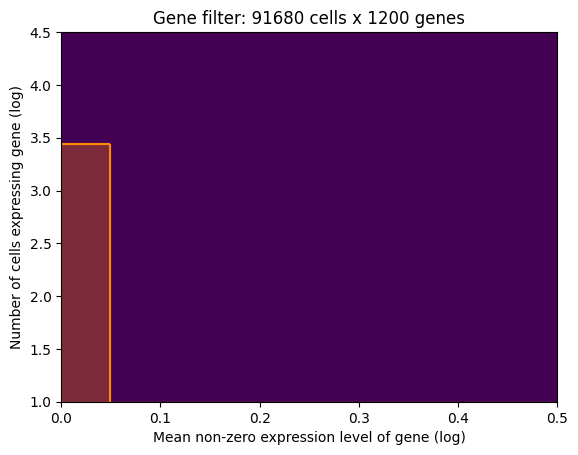

   Après filtre QC : 1211 gènes
   Gènes finaux spatial : 1211

🔬 Modèle de référence...
   Types : 21
   Samples : 87


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 250/250: 100%|██████████| 250/250 [19:28<00:00,  5.10s/it, v_num=1, elbo_train=3.46e+7]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [19:28<00:00,  4.67s/it, v_num=1, elbo_train=3.46e+7]


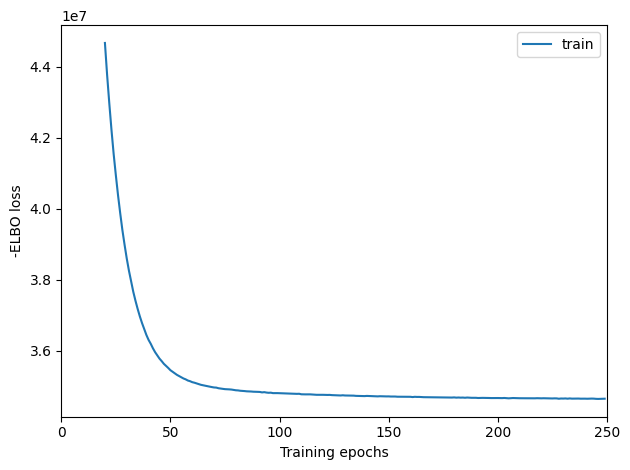

Sampling global variables, sample: 100%|██████████| 99/99 [00:01<00:00, 61.43it/s]
   💾 ref_model sauvegardé → ./cell2location_output/ref_model/
   Signatures : (1211, 21) | Max=270.13
   Gènes synchronisés : 1211

🗺️  Modèle spatial...


cell2location model with the following params: 
n_factors: 21 
n_batch: 60 
Training status: Not Trained

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.




🚀 Entraînement (CPU)...
Epoch 92/10000:   1%|          | 91/10000 [18:31:24<2029:17:27, 737.25s/it, v_num=1, elbo_train=8.43e+8]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Exception raised during training. <class 'NameError'> 1


SystemExit: 1

In [ ]:
"""
Cell2location — Pipeline Complet Corrigé
==========================================
Référence  : adata       (scRNA-seq  91k cellules)
Spatial    : adata_spatial (CosMx/Xenium 254k cellules)
Hardware   : GPU si disponible, sinon CPU
"""

import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import scipy.stats as stats
import cell2location
from cell2location.models import RegressionModel
import torch
import warnings
import os
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# 0. PARAMÈTRES
# ─────────────────────────────────────────────────────────────

OUTPUT_DIR           = "./cell2location_output"
CELL_TYPE_COL        = "annot_final2"
SAMPLE_COL_REF       = "orig_ident"
SAMPLE_COL_SPATIAL   = "orig_ident"
N_CELLS_PER_LOCATION = 3
DETECTION_ALPHA      = 20
MAX_EPOCHS_REF       = 250
MAX_EPOCHS_SPATIAL   = 10000

os.makedirs(OUTPUT_DIR, exist_ok=True)
sc.settings.figdir = OUTPUT_DIR

# Détection GPU/CPU
if torch.cuda.is_available():
    accelerator = "gpu"
    vram_gb     = torch.cuda.get_device_properties(0).total_memory / 1e9
    batch_size  = 8000 if vram_gb < 14 else 20000
    print(f"✅ GPU : {torch.cuda.get_device_name(0)} ({vram_gb:.1f} GB)")
    print(f"   batch_size : {batch_size}")
else:
    accelerator = "cpu"
    batch_size  = 25000
    n_cores     = os.cpu_count()
    torch.set_num_threads(n_cores)
    print(f"⚠️  CPU ({n_cores} cores)")


# ─────────────────────────────────────────────────────────────
# 1. OBJETS EN MÉMOIRE — CORRECTION CRITIQUE
# ─────────────────────────────────────────────────────────────

print("\n📂 Chargement des objets...")

# ✅ adata1       = scRNA-seq référence  (91k cellules × 2580 gènes)
# ✅ adata_immune = spatial immunitaire  (254k cellules × 5443 gènes)
adata_ref     = adata_immune.copy()        # référence scRNA-seq
adata_spatial = adata_spatial.copy()  # données spatiales immunitaires

print(f"   scRNA-seq  : {adata_ref.shape}")
print(f"   Spatial    : {adata_spatial.shape}")
print(f"\n   Annotations ({CELL_TYPE_COL}) :")
print(adata_ref.obs[CELL_TYPE_COL].value_counts())


# ─────────────────────────────────────────────────────────────
# 2. PRÉPARATION DES COUNTS
# ─────────────────────────────────────────────────────────────

print("\n⚙️  Préparation des counts...")

# scRNA-seq : log1p → expm1 (sans toarray → économise la RAM)
X_ref = adata_ref.layers['counts']
if scipy.sparse.issparse(X_ref):
    # Traitement en sparse pour éviter l'explosion mémoire
    X_ref_dense = X_ref.toarray()
else:
    X_ref_dense = np.array(X_ref)
X_ref_raw = np.round(np.expm1(X_ref_dense)).astype(np.float32)
adata_ref.X = scipy.sparse.csr_matrix(X_ref_raw)
del X_ref_dense
print(f"   scRNA-seq : Min={X_ref_raw.min():.0f} Max={X_ref_raw.max():.0f} ✅")
del X_ref_raw

# Spatial : counts bruts entiers — traitement chunk par chunk si nécessaire
X_sp = adata_spatial.layers['counts']
if scipy.sparse.issparse(X_sp):
    # Garder en sparse directement — pas besoin de toarray
    adata_spatial.X = X_sp.astype(np.float32)
else:
    adata_spatial.X = scipy.sparse.csr_matrix(X_sp.astype(np.float32))
print(f"   Spatial   : sparse matrix conservée ✅")

# Nettoyage annotation
n_before  = adata_ref.n_obs
adata_ref = adata_ref[adata_ref.obs[CELL_TYPE_COL].notna()].copy()
adata_ref = adata_ref[adata_ref.obs[CELL_TYPE_COL].astype(str) != 'Unknown'].copy()
print(f"   Cellules ref après nettoyage : {adata_ref.n_obs:,}")


# ─────────────────────────────────────────────────────────────
# 3. GÈNES PARTAGÉS + FILTRE QC
# ─────────────────────────────────────────────────────────────

print("\n🔎 Harmonisation des gènes...")

shared        = adata_ref.var_names.intersection(adata_spatial.var_names)
print(f"   Gènes partagés : {len(shared)}")
adata_ref     = adata_ref[:, shared].copy()
adata_spatial = adata_spatial[:, shared].copy()

cell2location.utils.filtering.filter_genes(
    adata_ref,
    cell_count_cutoff=5,
    cell_percentage_cutoff2=0.03,
    nonz_mean_cutoff=1.12
)
print(f"   Après filtre QC : {adata_ref.n_vars} gènes")

shared_final  = adata_ref.var_names.intersection(adata_spatial.var_names)
adata_spatial = adata_spatial[:, shared_final].copy()
print(f"   Gènes finaux spatial : {adata_spatial.n_vars}")


# ─────────────────────────────────────────────────────────────
# 4. MODÈLE DE RÉFÉRENCE
# ─────────────────────────────────────────────────────────────

print(f"\n🔬 Modèle de référence...")
print(f"   Types : {adata_ref.obs[CELL_TYPE_COL].nunique()}")
print(f"   Samples : {adata_ref.obs[SAMPLE_COL_REF].nunique()}")

RegressionModel.setup_anndata(
    adata      = adata_ref,
    batch_key  = SAMPLE_COL_REF,
    labels_key = CELL_TYPE_COL,
)

ref_model = RegressionModel(adata_ref)
ref_model.train(
    max_epochs  = MAX_EPOCHS_REF,
    accelerator = accelerator,
    batch_size  = 2500,
)

ref_model.plot_history(20)
plt.savefig(f"{OUTPUT_DIR}/ref_model_loss.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Export signatures
adata_ref = ref_model.export_posterior(
    adata_ref,
    sample_kwargs={'num_samples': 100, 'batch_size': 2500}
)
ref_model.save(f"{OUTPUT_DIR}/ref_model", overwrite=True)
print(f"   💾 ref_model sauvegardé → {OUTPUT_DIR}/ref_model/")

# Extraction inf_aver
factor_names = list(adata_ref.obs[CELL_TYPE_COL].cat.categories)
arr          = np.array(adata_ref.varm['means_per_cluster_mu_fg'])
inf_aver     = pd.DataFrame(arr, index=adata_ref.var_names,
                             columns=factor_names).fillna(0).clip(lower=0)
print(f"   Signatures : {inf_aver.shape} | Max={inf_aver.values.max():.2f}")

# Synchroniser gènes
common        = inf_aver.index.intersection(adata_spatial.var_names)
inf_aver      = inf_aver.loc[common]
adata_spatial = adata_spatial[:, common].copy()
print(f"   Gènes synchronisés : {len(common)}")


# ─────────────────────────────────────────────────────────────
# 5. MODÈLE SPATIAL
# ─────────────────────────────────────────────────────────────

print(f"\n🗺️  Modèle spatial...")
torch.cuda.empty_cache()

cell2location.models.Cell2location.setup_anndata(
    adata     = adata_spatial,
    batch_key = SAMPLE_COL_SPATIAL
)

spatial_model = cell2location.models.Cell2location(
    adata_spatial,
    cell_state_df        = inf_aver,
    N_cells_per_location = N_CELLS_PER_LOCATION,
    detection_alpha      = DETECTION_ALPHA,
)
print(spatial_model)

print(f"\n🚀 Entraînement ({accelerator.upper()})...")
spatial_model.train(
    max_epochs  = MAX_EPOCHS_SPATIAL,
    batch_size  = batch_size,
    train_size  = 1,
    accelerator = accelerator,
    lr          = 0.002,
)

spatial_model.plot_history(1000)
plt.savefig(f"{OUTPUT_DIR}/spatial_model_loss.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Sauvegarde immédiate
spatial_model.save(f"{OUTPUT_DIR}/spatial_model", overwrite=True)
print(f"   💾 spatial_model sauvegardé → {OUTPUT_DIR}/spatial_model/")


# ─────────────────────────────────────────────────────────────
# 6. EXPORT POSTERIOR
# ─────────────────────────────────────────────────────────────

print("\n📤 Export du posterior...")
adata_spatial = spatial_model.export_posterior(
    adata_spatial,
    sample_kwargs={'num_samples': 200, 'batch_size': 10000}
)

spatial_model.plot_QC()
plt.savefig(f"{OUTPUT_DIR}/spatial_model_QC.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Abondances dans obs
cell_types = list(adata_ref.obs[CELL_TYPE_COL].cat.categories)
q05        = np.array(adata_spatial.obsm['q05_cell_abundance_w_sf'])
for i, ct in enumerate(cell_types):
    adata_spatial.obs[ct] = q05[:, i]

print(f"\n✅ {len(cell_types)} types déconvolués :")
print(adata_spatial.obs[cell_types].sum().sort_values(ascending=False).round(2))

# Sauvegarde H5AD
out_path = f"{OUTPUT_DIR}/adata_immune_cell2location_final.h5ad"
adata_spatial.write_h5ad(out_path)
print(f"\n💾 H5AD sauvegardé → {out_path}")

# Vérification
test = sc.read_h5ad(out_path)
print(f"✅ Fichier vérifié : {test.shape}")
del test


# ─────────────────────────────────────────────────────────────
# 7. ANALYSES POST-DÉCONVOLUTION
# ─────────────────────────────────────────────────────────────

print("\n📊 Analyses post-déconvolution...")

# Séparer CosMx et Xenium
adata_cosmx  = adata_spatial[adata_spatial.obs['tech'] == 'CosMx'].copy()
adata_xenium = adata_spatial[adata_spatial.obs['tech'] == 'Xenium'].copy()
q05_cosmx    = np.array(adata_cosmx.obsm['q05_cell_abundance_w_sf'])
q05_xenium   = np.array(adata_xenium.obsm['q05_cell_abundance_w_sf'])

print(f"   CosMx  : {adata_cosmx.n_obs:,} cellules")
print(f"   Xenium : {adata_xenium.n_obs:,} cellules")


def run_analysis(adata, q05_data, tech_name):
    """Pipeline d'analyse par technologie"""
    plots_dir = os.path.join(OUTPUT_DIR, 'plots', tech_name)
    os.makedirs(plots_dir, exist_ok=True)
    print(f"\n{'='*60}")
    print(f"  ANALYSES — {tech_name} ({adata.n_obs:,} cellules)")
    print(f"{'='*60}")

    mean_ab = q05_data.mean(axis=0)
    ab_df   = pd.DataFrame({'cell_type': cell_types, 'mean_abundance': mean_ab})
    ab_df   = ab_df.sort_values('mean_abundance', ascending=False)
    top6    = ab_df['cell_type'].head(6).tolist()

    # ── 1. Abondance globale ──────────────────────────────────
    print(f"\n📊 [{tech_name}] Abondance globale")
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(ab_df['cell_type'], ab_df['mean_abundance'],
           color='steelblue', edgecolor='white')
    ax.set_xticklabels(ab_df['cell_type'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Abondance moyenne (q05)")
    ax.set_title(f"Abondance globale — {tech_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "01_mean_abundance.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── 2. Cartes spatiales ───────────────────────────────────
    print(f"\n🗺️  [{tech_name}] Cartes spatiales")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f"Top 6 types immuns — {tech_name}", fontsize=14, fontweight='bold')
    for ax, ct in zip(axes.flat, top6):
        sc.pl.embedding(adata, basis="spatial", color=ct, size=0.5,
                        cmap='RdYlBu_r', frameon=False, title=ct, ax=ax, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "02_spatial_top6_grid.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    for ct in cell_types:
        safe_ct = ct.replace('/', '_').replace(' ', '_').replace('+', 'pos')
        fig, ax = plt.subplots(figsize=(8, 8))
        sc.pl.embedding(adata, basis="spatial", color=ct, size=1,
                        cmap='RdYlBu_r', frameon=False,
                        title=f"{ct} — {tech_name}", ax=ax, show=False)
        plt.savefig(os.path.join(plots_dir, f"02_spatial_{safe_ct}.png"),
                    dpi=150, bbox_inches='tight')
        plt.close()
    print(f"   ✅ {len(cell_types)} cartes générées")

    # ── 3. Ctrl vs CKD ───────────────────────────────────────
    print(f"\n⚖️  [{tech_name}] Ctrl vs CKD")
    conditions  = adata.obs['Condition'].dropna().unique()
    colors_cond = ['#4E9AF1', '#E05C5C']

    fig, axes = plt.subplots(1, len(conditions), figsize=(8 * len(conditions), 7))
    if len(conditions) == 1:
        axes = [axes]
    for ax, cond, col in zip(axes, conditions, colors_cond):
        mask = adata.obs['Condition'] == cond
        ax.barh(cell_types, q05_data[mask.values].mean(axis=0), color=col)
        ax.set_title(cond, fontsize=12, fontweight='bold')
        ax.set_xlabel("Abondance (q05)")
    plt.suptitle(f"Ctrl vs CKD — {tech_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "03_abundance_Ctrl_vs_CKD.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # Tests Mann-Whitney
    results = []
    for i, ct in enumerate(cell_types):
        ctrl_vals = q05_data[adata.obs['Condition'] == conditions[0], i]
        ckd_vals  = q05_data[adata.obs['Condition'] == conditions[1], i]
        if len(ctrl_vals) == 0 or len(ckd_vals) == 0:
            continue
        _, pval = stats.mannwhitneyu(ctrl_vals, ckd_vals, alternative='two-sided')
        log2fc  = np.log2((ckd_vals.mean() + 1e-6) / (ctrl_vals.mean() + 1e-6))
        results.append({'cell_type': ct, 'mean_ctrl': ctrl_vals.mean(),
                        'mean_ckd': ckd_vals.mean(), 'log2FC': log2fc,
                        'pvalue': pval, 'padj': pval * len(cell_types),
                        'significant': pval < 0.05})

    results_df = pd.DataFrame(results).sort_values('pvalue')
    results_df.to_csv(
        os.path.join(OUTPUT_DIR, f"03_{tech_name}_CKD_vs_Ctrl_stats.csv"), index=False)

    # Volcano
    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in results_df.iterrows():
        col = '#E05C5C' if (row['significant'] and row['log2FC'] > 0) else \
              '#4E9AF1' if (row['significant'] and row['log2FC'] < 0) else '#AAAAAA'
        ax.scatter(row['log2FC'], -np.log10(row['pvalue'] + 1e-300), color=col, s=80)
        if row['significant']:
            ax.annotate(row['cell_type'],
                        (row['log2FC'], -np.log10(row['pvalue'] + 1e-300)),
                        fontsize=7, ha='center', va='bottom')
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', lw=0.8)
    ax.axvline(0, color='black', linestyle='--', lw=0.8)
    ax.set_xlabel("log2FC (CKD / Ctrl)")
    ax.set_ylabel("-log10(p-value)")
    ax.set_title(f"Volcano — {tech_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "03_volcano.png"), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # ── 4. Corrélation Immune ME ──────────────────────────────
    print(f"\n🔗 [{tech_name}] Corrélation Immune ME")
    me_df   = pd.DataFrame(q05_data, index=adata.obs_names, columns=cell_types)
    me_df['Immune_ME'] = adata.obs['Immune_ME_20um'].values
    me_mean = me_df.groupby('Immune_ME')[cell_types].mean()

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(me_mean.T, cmap='RdYlBu_r', ax=ax, linewidths=0.5,
                annot=True, fmt='.1f', cbar_kws={'label': 'Abondance (q05)'})
    ax.set_title(f"Abondance par Immune ME — {tech_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "04_heatmap_by_ME.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    me_mean_z = me_mean.apply(lambda x: (x - x.mean()) / (x.std() + 1e-6), axis=0)
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(me_mean_z.T, cmap='RdBu_r', ax=ax, linewidths=0.5,
                center=0, cbar_kws={'label': 'Z-score'})
    ax.set_title(f"Z-score par Immune ME — {tech_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "04_heatmap_zscore_by_ME.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    me_mean.to_csv(os.path.join(OUTPUT_DIR, f"04_{tech_name}_abundance_by_ME.csv"))

    # ── 5. Nhood enrichment + Moran's I ──────────────────────
    print(f"\n🔬 [{tech_name}] Nhood enrichment + Moran's I")

    sq.gr.spatial_neighbors(
        adata,
        spatial_key = 'spatial',
        radius      = 20,
        coord_type  = 'generic',
    )

    sq.gr.nhood_enrichment(
        adata,
        cluster_key = 'immune_cell_annotation_combined',
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    sq.pl.nhood_enrichment(
        adata,
        cluster_key = 'immune_cell_annotation_combined',
        ax          = ax,
        title       = f"Co-localisation — {tech_name}",
    )
    plt.savefig(os.path.join(plots_dir, "05_nhood_enrichment.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    genes_interest = [g for g in [
        'MS4A1', 'CD19', 'CD79A', 'CD3D', 'CD3E',
        'CD4', 'CD8A', 'CD68', 'MRC1', 'MARCO',
        'CXCL13', 'CCL19', 'CCL21', 'PDCD1',
        'HAVCR2', 'FOXP3', 'TREM2', 'FOLR2',
    ] if g in adata.var_names]

    if genes_interest:
        sq.gr.spatial_autocorr(
            adata, genes=genes_interest, mode='moran'
        )
        # Récupérer la clé Moran's I (peut varier selon version squidpy)
        moran_key = 'moranI' if 'moranI' in adata.uns else \
                    [k for k in adata.uns.keys() if 'moran' in k.lower()]
        if isinstance(moran_key, list) and len(moran_key) > 0:
            moran_key = moran_key[0]
        if moran_key in adata.uns:
            moran_df = adata.uns[moran_key].sort_values('I', ascending=False)
            moran_df.to_csv(
                os.path.join(OUTPUT_DIR, f"05_{tech_name}_moranI.csv"))
            print(f"   Top gènes spatiaux ({tech_name}) :")
            print(moran_df.head(10)[['I', 'pval_norm']])

    # ── 6. CellPhoneDB ────────────────────────────────────────
    print(f"\n📡 [{tech_name}] Préparation CellPhoneDB")
    cpdb_dir = os.path.join(OUTPUT_DIR, 'cellphonedb', tech_name)
    os.makedirs(cpdb_dir, exist_ok=True)

    adata_cpdb = adata.copy()
    adata_cpdb.obs['annotation_updated'] = \
        adata_cpdb.obs['annotation_updated'].fillna('Immune')
    adata_cpdb.obs['cpdb_annotation'] = np.where(
        adata_cpdb.obs['annotation_updated'] != 'Immune',
        adata_cpdb.obs['annotation_updated'],
        adata_cpdb.obs['immune_cell_annotation_combined']
    )
    adata_cpdb.obs['microenvironment'] = (
        adata_cpdb.obs['Immune_ME_20um'].astype(str) + '_' +
        adata_cpdb.obs['orig_ident'].astype(str)
    )

    me_counts  = adata_cpdb.obs['microenvironment'].value_counts()
    valid_me   = me_counts[me_counts >= 50].index
    adata_cpdb = adata_cpdb[adata_cpdb.obs['microenvironment'].isin(valid_me)].copy()

    adata_cpdb.obs['me_cell_type'] = (
        adata_cpdb.obs['microenvironment'].astype(str) + '_' +
        adata_cpdb.obs['cpdb_annotation'].astype(str)
    )

    me_ct_counts = adata_cpdb.obs['me_cell_type'].value_counts()
    valid_me_ct  = me_ct_counts[me_ct_counts >= 10].index
    adata_cpdb   = adata_cpdb[adata_cpdb.obs['me_cell_type'].isin(valid_me_ct)].copy()

    metadata = adata_cpdb.obs[['me_cell_type']].copy()
    metadata['barcode_sample'] = adata_cpdb.obs_names
    metadata.rename(columns={'me_cell_type': 'cell_type'})[
        ['barcode_sample', 'cell_type']
    ].to_csv(os.path.join(cpdb_dir, "metadata.csv"), index=False)

    adata_cpdb.obs[['me_cell_type', 'microenvironment']].rename(
        columns={'me_cell_type': 'cell_type'}
    )[['cell_type', 'microenvironment']].to_csv(
        os.path.join(cpdb_dir, "microenvironment.csv"), index=False)

    adata_cpdb.write_h5ad(os.path.join(cpdb_dir, "adata_for_cellphonedb.h5ad"))
    print(f"   ✅ CellPhoneDB prêt → {cpdb_dir}/")

    print(f"\n✅ [{tech_name}] Toutes les analyses terminées !")
    return results_df, me_mean


# ─────────────────────────────────────────────────────────────
# LANCER LES ANALYSES
# ─────────────────────────────────────────────────────────────

print("\n🚀 Lancement des analyses séparées CosMx et Xenium...\n")

results_cosmx,  me_cosmx  = run_analysis(adata_cosmx,  q05_cosmx,  "CosMx")
results_xenium, me_xenium = run_analysis(adata_xenium, q05_xenium, "Xenium")


# ─────────────────────────────────────────────────────────────
# COMPARAISON CosMx vs Xenium
# ─────────────────────────────────────────────────────────────

print("\n📊 Comparaison CosMx vs Xenium...")
combined_dir = os.path.join(OUTPUT_DIR, 'plots', 'combined')
os.makedirs(combined_dir, exist_ok=True)

mean_cosmx  = pd.Series(q05_cosmx.mean(axis=0),  index=cell_types)
mean_xenium = pd.Series(q05_xenium.mean(axis=0), index=cell_types)
corr, pval  = stats.pearsonr(mean_cosmx, mean_xenium)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(mean_cosmx, mean_xenium, s=100, color='steelblue', edgecolors='white')
for ct in cell_types:
    ax.annotate(ct, (mean_cosmx[ct], mean_xenium[ct]), fontsize=7)
ax.set_xlabel("Abondance CosMx (q05)")
ax.set_ylabel("Abondance Xenium (q05)")
ax.set_title(f"Corrélation CosMx vs Xenium\nr={corr:.3f}, p={pval:.3e}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(combined_dir, "correlation_CosMx_vs_Xenium.png"),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"   r={corr:.3f}, p={pval:.3e}")


# ─────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("✅ PIPELINE COMPLET TERMINÉ")
print("="*60)
print(f"\n📁 Résultats dans : {OUTPUT_DIR}/")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f)) / 1e6
        print(f'{"  "*(level+1)}{f:45s} {size:.1f} MB')

In [ ]:
import os
import os

# ── Chemin Windows correct ────────────────────────────────────
# Place model.pt manuellement dans ce dossier via l'explorateur :
spatial_model_dir = r"C:\Users\RICHMOND\Documents\Richmond\singlecell_rein\script_exemple\data2\xemuin\cell2location_output\ref_model"

# Vérifier que le fichier est bien là
model_path = os.path.join(spatial_model_dir, "model.pt")
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / 1e6
    print(f"✅ model.pt trouvé : {size:.1f} MB")
else:
    print(f"❌ model.pt non trouvé dans :")
    print(f"   {spatial_model_dir}")
    print(f"\nContenu du dossier :")
    if os.path.exists(spatial_model_dir):
        for f in os.listdir(spatial_model_dir):
            print(f"   {f}")
    else:
        print("   Dossier inexistant")

✅ model.pt trouvé : 2.2 MB


In [ ]:
# Counts bruts
X_sp = adata_spatial.layers['counts']
if hasattr(X_sp, 'toarray'):
    X_sp = X_sp.toarray()
adata_spatial.X = scipy.sparse.csr_matrix(X_sp.astype(np.float32))

# Synchroniser sur les mêmes gènes qu'à l'entraînement
common = inf_aver.index.intersection(adata_spatial.var_names)
adata_spatial = adata_spatial[:, common].copy()
print(f"✅ adata_spatial reconstruit : {adata_spatial.shape}")

NameError: name 'adata_spatial' is not defined

In [ ]:
adata_spatial

NameError: name 'adata_spatial' is not defined